## Experimente

Verändert jeweils nur einen Parameter:

### 1. Mehr Schichten
Vergleiche:
- `784 → 64 → 10`
- `784 → 512 → 256 → 128 → 10`

Frage:
- Wird das Modell besser?
- Wie verändert sich die Trainingszeit?


### 2. Aktivierungsfunktion

Vergleiche:

- ReLU
- Sigmoid
- Tanh

Frage:
- Warum funktioniert ReLU meistens besser?


### 3. Dropout

Vergleiche:
- `dropout_rate=0.0`
- `dropout_rate=0.5`

Frage:
- Warum kann ein schlechteres Trainingsergebnis trotzdem ein besseres Modell ergeben?


### 4. Lernrate

Teste:
- `learning_rate = 0.0001`
- `learning_rate = 0.001`
- `learning_rate = 0.01`

Frage:
- Was passiert bei zu kleinen oder zu großen Schritten?


## setup

In [ ]:
# This cell just defined all functions needed
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import time
import pandas as pd
import matplotlib.pyplot as plt


def build_model(
    input_size=784,
    hidden_layers=[128, 64],
    activation="relu",
    dropout_rate=0.0,
    output_classes=10,
    output_activation="softmax",
    learning_rate=0.001
):
    """
    Erstellt ein vollständig verbundenes neuronales Netzwerk.

    Parameters
    ----------
    input_size:
        Anzahl Eingabewerte (MNIST: 784 Pixel)

    hidden_layers:
        Liste mit Anzahl Neuronen pro versteckter Schicht

    activation:
        Aktivierungsfunktion der versteckten Schichten

    dropout_rate:
        Anteil der ausgeschalteten Neuronen während Training

    output_classes:
        Anzahl Klassen

    learning_rate:
        Schrittweite beim Lernen
    """


    model = keras.Sequential()


    # Input + Hidden Layers

    for i, neurons in enumerate(hidden_layers):
        if i == 0:
            model.add( layers.Dense( neurons, activation=activation, input_shape=(input_size,), name=f"hidden_layer_{i+1}"))
        else:
            model.add( layers.Dense( neurons, activation=activation, name=f"hidden_layer_{i+1}"))
        if dropout_rate > 0:
            model.add( layers.Dropout( dropout_rate, name=f"dropout_{i+1}"))
    # Output layer
    model.add( layers.Dense( output_classes, activation=output_activation, name="output_layer"))
    optimizer = keras.optimizers.Adam( learning_rate=learning_rate)
    model.compile( optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def train(model, X, y, epoche=15, batch_size=32, validation_split=0.2, verbose=1):
    # Training mit Validierungsdaten
    print("Training startet...\n")
    start_time = time.time()
    history = model.fit( X, y, epochs=epoche, batch_size=batch_size, validation_split=validation_split, verbose=verbose)
    training_time = time.time() - start_time
    print(f"\n✓ Training beendet in {training_time:.2f} Sekunden")
    return history, training_time

def visualize(history):
    # Trainings-Verlauf plotten
    _, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Loss-Plot
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validierung Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss über Zeit')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy-Plot
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validierung Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Genauigkeit über Zeit')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Letzte Werte anzeigen
    print(f"Finaler Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Finaler Validierung Loss: {history.history['val_loss'][-1]:.4f}")
    print(f"Finaler Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Finaler Validierung Accuracy: {history.history['val_accuracy'][-1]:.4f}")

def test(model, X, y, verobse=0):
# Testset evaluieren
    test_loss, test_accuracy = model.evaluate(X, y, verbose=verobse)

    print("\n" + "="*50)
    print("TESTSET ERGEBNISSE")
    print("="*50)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print("="*50)
    return test_loss, test_accuracy

def save_model(model, model_path='mnist_model.h5'):
    # Modell speichern
    model.save(model_path)
    print(f"✓ Modell gespeichert: {model_path}")

def load_model(model, model_path='mnist_model.h5', X=None, y=None):
    # Später wieder laden und testen
    loaded_model = keras.models.load_model(model_path)
    if X and y:
        loaded_test_acc = loaded_model.evaluate(X, y)[1]
        print(f"✓ Modell geladen und getestet: {loaded_test_acc:.4f} ({loaded_test_acc*100:.2f}%)")
    return load_model

def create_result_entry( name, history, training_time, test_loss, test_accuracy):
    return { "name": name, "history": history, "training_time": training_time, "test_loss": test_loss, "test_accuracy": test_accuracy }

def results_table(results):
    data = []
    for r in results:
        data.append({ "Modell": r["name"], "Test Accuracy": r["test_accuracy"], "Test Loss": r["test_loss"], "Trainingszeit (s)": r["training_time"] })
    return pd.DataFrame(data)

def visualize_experiment_results(results):
    names = [ r["name"] for r in results ]
    accuracies = [ r["test_accuracy"] for r in results ]
    times = [ r["training_time"] for r in results ]
    _, axes = plt.subplots( 1, 2, figsize=(12,4))
    # Accuracy
    axes[0].bar( names, accuracies)
    axes[0].set_ylim( 0, 1)
    axes[0].set_ylabel( "Test Accuracy")
    axes[0].set_title( "Vergleich der Genauigkeit")
    # Training time
    axes[1].bar( names, times)
    axes[1].set_ylabel( "Sekunden")
    axes[1].set_title( "Trainingszeit")
    plt.tight_layout()
    plt.show()

def visualize_learning_curves(results):
    plt.figure(figsize=(8,5))
    for r in results:
        history = r["history"]
        plt.plot( history.history["accuracy"], label=r["name"])
    plt.xlabel( "Epoche")
    plt.ylabel( "Training Accuracy")
    plt.title( "Lernkurven vergleichen")
    plt.grid()
    plt.legend()
    plt.show()

## Experiments

In [ ]:
# MNIST-Daten laden
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Rohdaten geladen:")
print(f"  Training: {x_train.shape}, Labels: {y_train.shape}")
print(f"  Test: {x_test.shape}, Labels: {y_test.shape}")

# Daten vorbereiten: Reshape und Normalisieren
x_train_flat = x_train.reshape(-1, 784) / 255.0
x_test_flat = x_test.reshape(-1, 784) / 255.0

# One-Hot Encoding der Labels
y_train_encoded = keras.utils.to_categorical(y_train, 10)
y_test_encoded = keras.utils.to_categorical(y_test, 10)

print("\nDaten vorbereitet:")
print(f"  Training Bilder: {x_train_flat.shape}")
print(f"  Training Labels (One-Hot): {y_train_encoded.shape}")
print(f"  Pixel-Bereich: [{x_train_flat.min():.2f}, {x_train_flat.max():.2f}]")

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9666 - loss: 0.1123 - val_accuracy: 0.9644 - val_loss: 0.1168
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9760 - loss: 0.0776 - val_accuracy: 0.9687 - val_loss: 0.1034
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9819 - loss: 0.0590 - val_accuracy: 0.9718 - val_loss: 0.0986
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9847 - loss: 0.0481 - val_accuracy: 0.9723 - val_loss: 0.0994
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9885 - loss: 0.0361 - val_accuracy: 0.9747 - val_loss: 0.0891
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9901 - loss: 0.0292 - val_accuracy: 0.9753 - val_loss: 0.0976
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9914 - loss: 0.0261 - val_accuracy: 0.9771 - val_loss: 0.0888
Epoch 9/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9928 - loss: 0.0206 - val_accurac

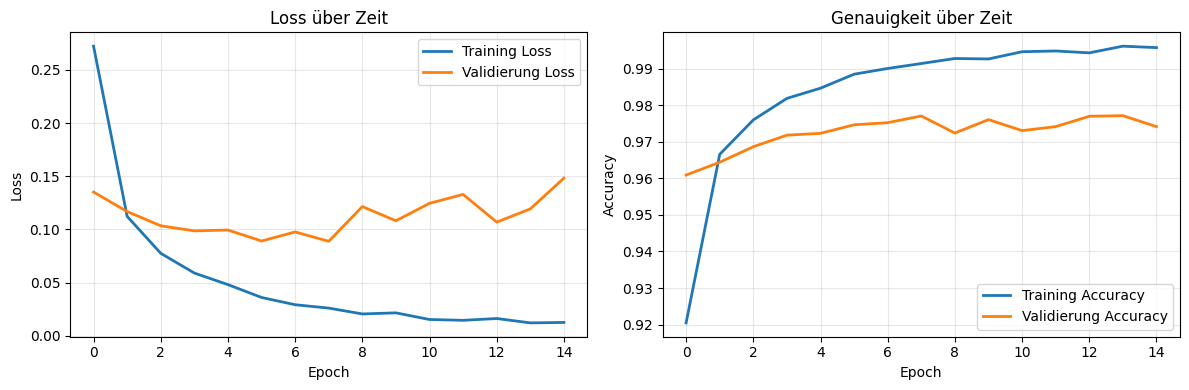

Finaler Training Loss: 0.0126
Finaler Validierung Loss: 0.1482
Finaler Training Accuracy: 0.9958
Finaler Validierung Accuracy: 0.9742

TESTSET ERGEBNISSE
Test Loss: 0.1286
Test Accuracy: 0.9755 (97.55%)
Aktivierung: sigmoid


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Training startet...

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8673 - loss: 0.5358 - val_accuracy: 0.9327 - val_loss: 0.2330
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9410 - loss: 0.1988 - val_accuracy: 0.9536 - val_loss: 0.1618
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9585 - loss: 0.1395 - val_accuracy: 0.9633 - val_loss: 0.1298
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9691 - loss: 0.1052 - val_accuracy: 0.9679 - val_loss: 0.1118
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9757 - loss: 0.0822 - val_accuracy: 0.9696 - val_loss: 0.1086
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9809 - loss: 0.0665 - val_accuracy: 0.9728 - val_loss: 0.0919
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9844 - loss: 0.0534 - val_accuracy: 0.9688 - val_loss: 0.0992
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9

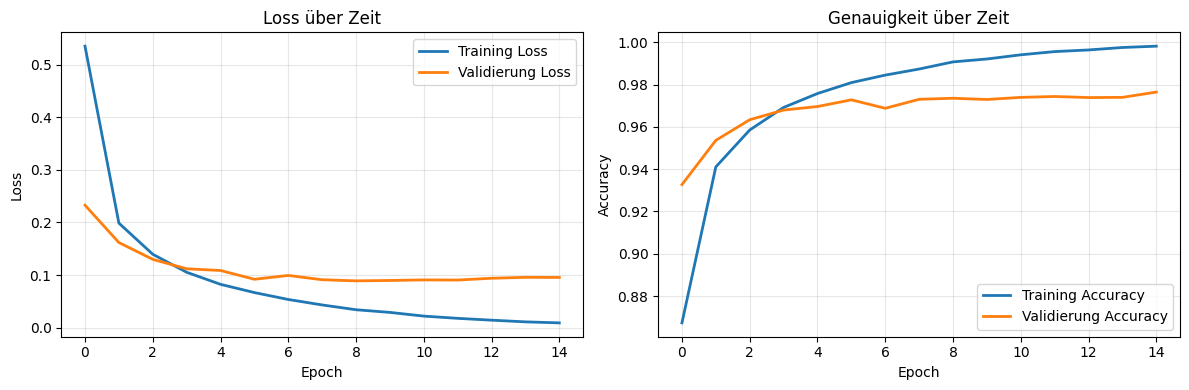

Finaler Training Loss: 0.0088
Finaler Validierung Loss: 0.0953
Finaler Training Accuracy: 0.9981
Finaler Validierung Accuracy: 0.9764

TESTSET ERGEBNISSE
Test Loss: 0.0846
Test Accuracy: 0.9765 (97.65%)
Aktivierung: tanh


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Training startet...

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9135 - loss: 0.2955 - val_accuracy: 0.9542 - val_loss: 0.1616
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9586 - loss: 0.1371 - val_accuracy: 0.9647 - val_loss: 0.1237
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9731 - loss: 0.0904 - val_accuracy: 0.9671 - val_loss: 0.1096
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9803 - loss: 0.0649 - val_accuracy: 0.9697 - val_loss: 0.0996
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9851 - loss: 0.0489 - val_accuracy: 0.9697 - val_loss: 0.1051
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9887 - loss: 0.0369 - val_accuracy: 0.9732 - val_loss: 0.0900
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9910 - loss: 0.0287 - val_accuracy: 0.9743 - val_loss: 0.0947
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9

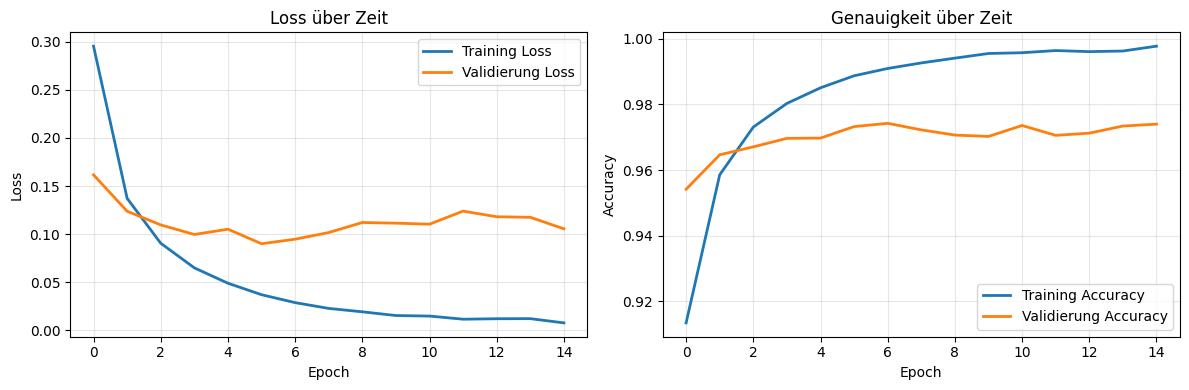

Finaler Training Loss: 0.0076
Finaler Validierung Loss: 0.1055
Finaler Training Accuracy: 0.9977
Finaler Validierung Accuracy: 0.9740

TESTSET ERGEBNISSE
Test Loss: 0.0973
Test Accuracy: 0.9760 (97.60%)
Experiment abgeschlossen!


In [9]:
activations = [
    "relu",
    "sigmoid",
    "tanh"
]


results = []


for activation in activations:
    print("="*50)
    print(f"Aktivierung: {activation}")
    model = build_model(
        hidden_layers=[128,64],
        activation=activation
    )
    model.summary()
    history, training_time = train(
        model,
        x_train_flat,
        y_train,
        epoche=15
    )
    visualize(history)
    test_loss, test_accuracy = test(
        model,
        x_test_flat,
        y_test
    )
    results.append(
        create_result_entry(
            name=activation,
            history=history,
            training_time=training_time,
            test_loss=test_loss,
            test_accuracy=test_accuracy
        )
    )
print("Experiment abgeschlossen!")

### Results compare

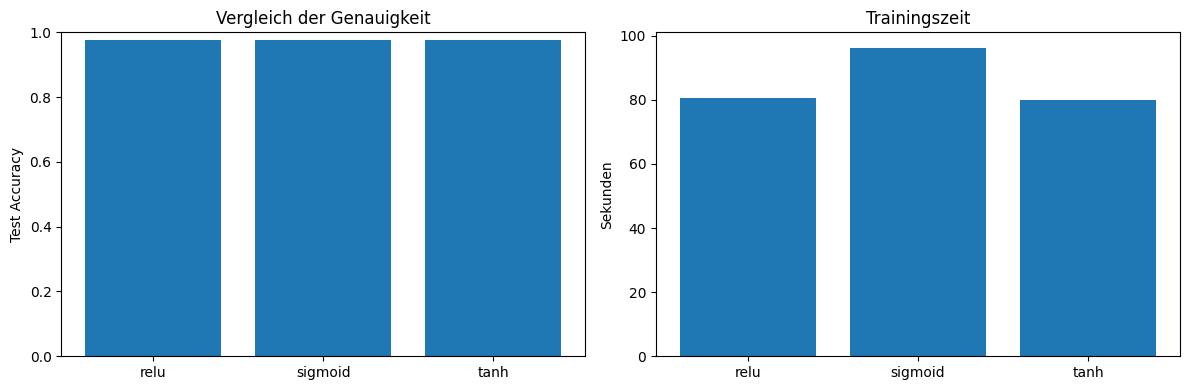

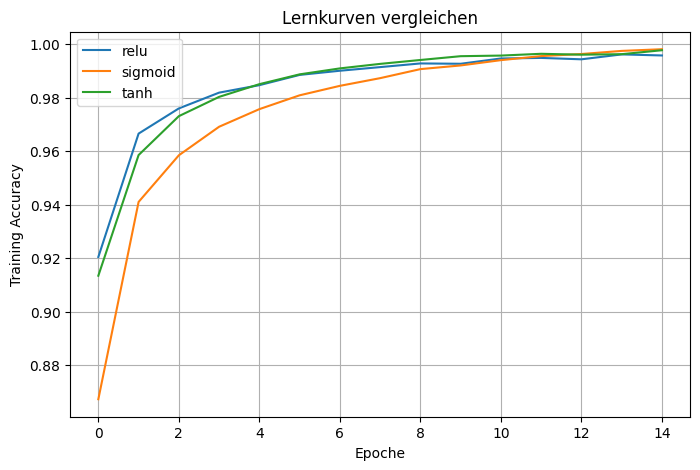

In [10]:
results_table(results)
visualize_experiment_results(results)
visualize_learning_curves(results)

Training startet...

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8845 - loss: 0.4100 - val_accuracy: 0.9323 - val_loss: 0.2427
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9350 - loss: 0.2260 - val_accuracy: 0.9388 - val_loss: 0.2086
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9477 - loss: 0.1805 - val_accuracy: 0.9523 - val_loss: 0.1683
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9564 - loss: 0.1492 - val_accuracy: 0.9553 - val_loss: 0.1562
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9615 - loss: 0.1313 - val_accuracy: 0.9570 - val_loss: 0.1468

✓ Training beendet in 18.05 Sekunden

TESTSET ERGEBNISSE
Test Loss: 0.1474
Test Accuracy: 0.9568 (95.68%)
Training startet...

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9202 - loss: 0.2695 - val_accuracy: 0.9525 - val_loss: 0.1493
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9663 - los

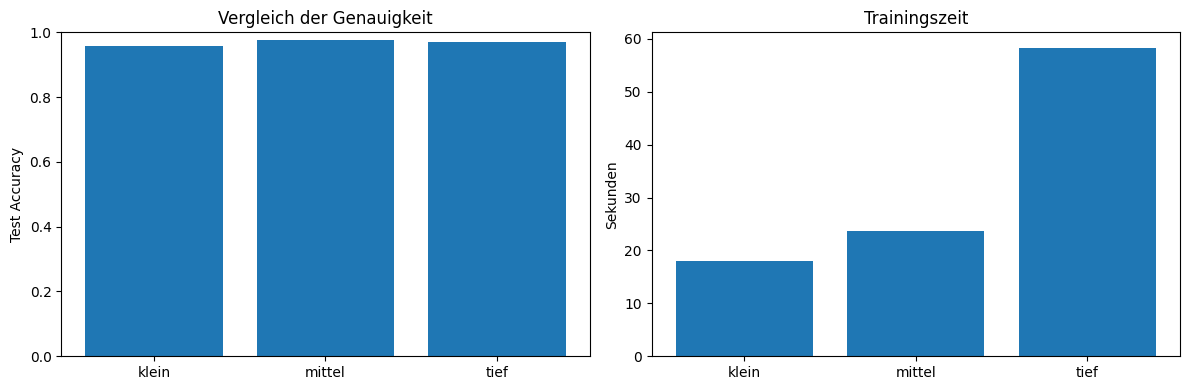

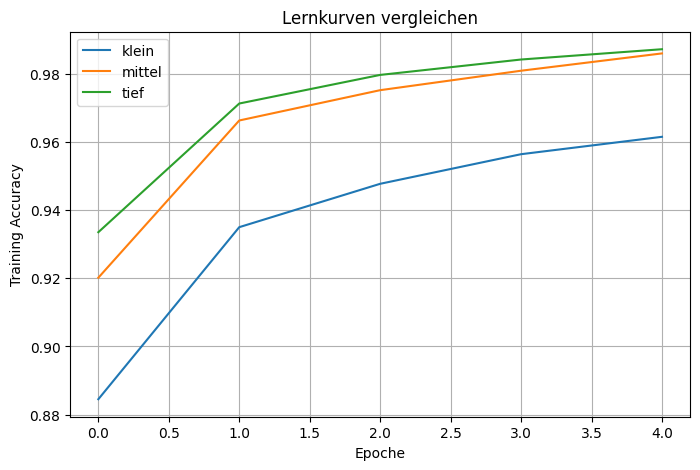

In [11]:
architectures = { "klein":[32], "mittel":[128,64], "tief":[512,256,128] }
results_layers = []
for name, architecture in architectures.items():
    model = build_model( hidden_layers=architecture)
    history, training_time = train( model, x_train_flat, y_train, epoche=5)
    loss, accuracy = test( model, x_test_flat, y_test)
    results_layers.append( create_result_entry( name, history, training_time, loss, accuracy))
results_table(results_layers)
visualize_experiment_results(results_layers)
visualize_learning_curves(results_layers)

Training startet...

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9212 - loss: 0.2739 - val_accuracy: 0.9557 - val_loss: 0.1422
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9649 - loss: 0.1144 - val_accuracy: 0.9620 - val_loss: 0.1289
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9760 - loss: 0.0778 - val_accuracy: 0.9718 - val_loss: 0.0942
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9819 - loss: 0.0578 - val_accuracy: 0.9687 - val_loss: 0.1037
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9852 - loss: 0.0466 - val_accuracy: 0.9743 - val_loss: 0.0903

✓ Training beendet in 28.50 Sekunden

TESTSET ERGEBNISSE
Test Loss: 0.0868
Test Accuracy: 0.9731 (97.31%)
Training startet...

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9060 - loss: 0.3160 - val_accuracy: 0.9557 - val_loss: 0.1494
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9562 - los

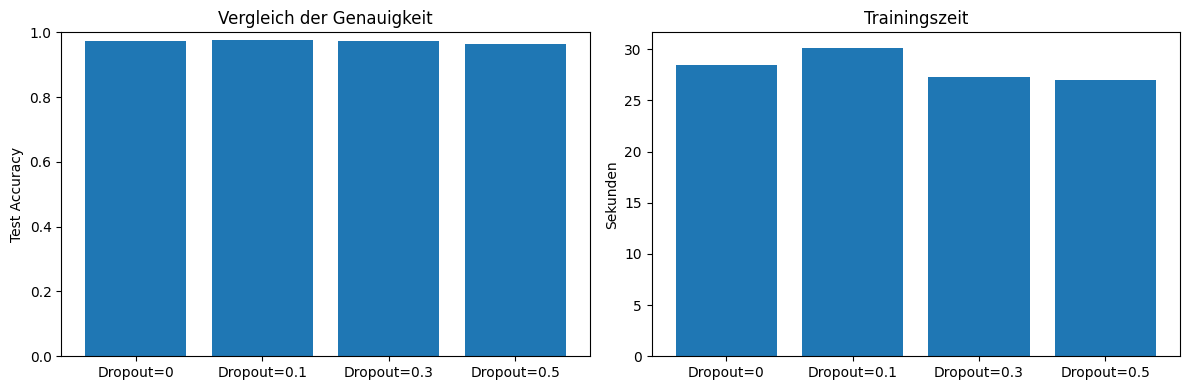

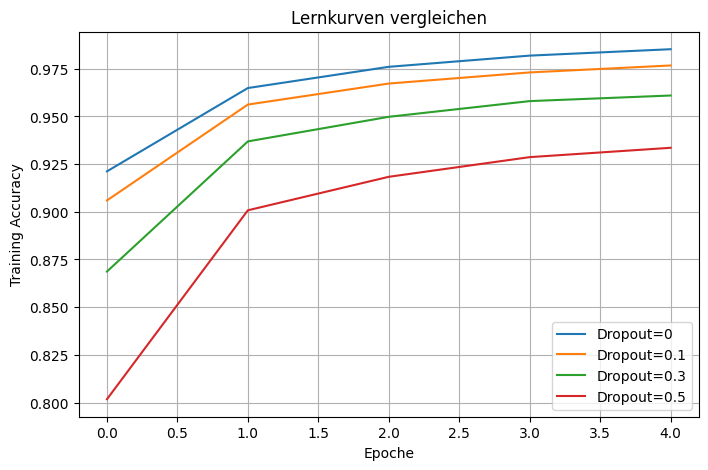

In [12]:
dropouts = [ 0, 0.1, 0.3, 0.5 ]
results_dropout = []
for d in dropouts:
    model = build_model( hidden_layers=[128,64], dropout_rate=d)
    history, training_time = train( model, x_train_flat, y_train, epoche=5)
    loss, accuracy = test( model, x_test_flat, y_test)
    results_dropout.append( create_result_entry( f"Dropout={d}", history, training_time, loss, accuracy))
results_table(results_dropout)
visualize_experiment_results(results_dropout)
visualize_learning_curves(results_dropout)

* more layers → deeper learning
* activation functions → nonlinearity
* dropout → generalization
* learning rate → gradient descent behavior.